In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Load Dataaset
conn = sqlite3.connect(r"C:\Project_Data\e_commerce_olist\data\olist.db")
df_mart = pd.read_sql(
    """
        SELECT *
        FROM mart_delivery_performance;
    """,
    conn
)
conn.close()

In [4]:
display(df_mart)
print(df_mart.info())

date_columns = [
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df_mart[col] = pd.to_datetime(df_mart[col], errors='coerce')

print(df_mart.info())

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18 00:00:00,4.0,SP
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13 00:00:00,4.0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04 00:00:00,5.0,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15 00:00:00,5.0,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26 00:00:00,5.0,SP
...,...,...,...,...,...
87022,9c5dedf39a927c1b2549525ed64a053c,2017-03-17 15:08:01,2017-03-28 00:00:00,5.0,SP
87023,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28 17:37:56,2018-03-02 00:00:00,4.0,SP
87024,83c1379a015df1e13d02aae0204711ab,2017-09-21 11:24:17,2017-09-27 00:00:00,5.0,BA
87025,11c177c8e97725db2631073c19f07b62,2018-01-25 23:32:54,2018-02-15 00:00:00,2.0,RJ


<class 'pandas.DataFrame'>
RangeIndex: 87027 entries, 0 to 87026
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       87027 non-null  str    
 1   order_delivered_customer_date  87027 non-null  str    
 2   order_estimated_delivery_date  87027 non-null  str    
 3   review_score                   87027 non-null  float64
 4   customer_state                 87027 non-null  str    
dtypes: float64(1), str(4)
memory usage: 3.3 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 87027 entries, 0 to 87026
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       87027 non-null  str           
 1   order_delivered_customer_date  87027 non-null  datetime64[us]
 2   order_estimated_delivery_date  87027 non-null  datetime64[us

# Distribution Diff Delivery Date

Rule : 
negatif (-) -> terlambat
0 -> on-time / tepat waktu
positif (+) -> lebih awal


In [5]:
df_mart['diff_delivery_date'] = (
    (df_mart['order_estimated_delivery_date'] - df_mart['order_delivered_customer_date']).dt.total_seconds() / 86400
).round(2)

print("Delay Days Descriptive :")
print(df_mart['diff_delivery_date'].describe().round(2), '\n')

def outlier_check(df, kolom) :

    q1 = df[kolom].quantile(0.25)
    q3 = df[kolom].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_df = df[(df[kolom] < lower_bound) | (df[kolom] > upper_bound)]

    return lower_bound, upper_bound, outlier_df

lower, upper, outlier_df = outlier_check(df=df_mart, kolom='diff_delivery_date')

print(f"Lower Bound Outlier : {lower:.2f}")
print(f"Upper Bound Outlier : {upper:.2f}")
print(f"Total Outlier : {outlier_df.shape[0]} / {round((outlier_df.shape[0] / df_mart.shape[0])*100, 2)}%")

Delay Days Descriptive :
count    87027.00
mean        11.79
std          9.70
min       -188.98
25%          7.18
50%         12.21
75%         16.46
max        146.02
Name: diff_delivery_date, dtype: float64 

Lower Bound Outlier : -6.74
Upper Bound Outlier : 30.38
Total Outlier : 4526 / 5.2%


In [6]:
delivery_delay = df_mart[df_mart['diff_delivery_date'] < 0]
delivery_delay['diff_delivery_date_abs'] = delivery_delay['diff_delivery_date'].abs()

print("Descriptive Delivery Delay :")
print(delivery_delay['diff_delivery_date_abs'].describe().round(2), '\n')

lower_delay, upper_delay, outlier_delay = outlier_check(df=delivery_delay, kolom='diff_delivery_date_abs')
print(f"Lower Bound Outlier : {abs(lower_delay):.2f}")
print(f"Upper Bound Outlier : {upper_delay:.2f}")
print(f"Total Outlier : {outlier_delay.shape[0]} / {round((outlier_delay.shape[0] / delivery_delay.shape[0])*100, 2)}%")

Descriptive Delivery Delay :
count    5574.00
mean        9.67
std        14.19
min         0.01
25%         1.84
50%         5.82
75%        11.96
max       188.98
Name: diff_delivery_date_abs, dtype: float64 

Lower Bound Outlier : 13.33
Upper Bound Outlier : 27.13
Total Outlier : 360 / 6.46%


In [7]:
delivery_delay['delay_category'] = pd.cut(
    delivery_delay['diff_delivery_date'],
    bins=[-float('inf'), -27.13, -11.96, -1.84, 0],
    labels=['Ekstrem', 'Parah', 'Sedang', 'Ringan']
)

print(f"Average Review Score by Delay Category :")
print(delivery_delay.groupby('delay_category')['review_score'].agg(['mean', 'count']))

Average Review Score by Delay Category :
                    mean  count
delay_category                 
Ekstrem         1.933333    360
Parah           1.668279   1034
Sedang          2.321518   2793
Ringan          3.948810   1387


In [8]:
df_mart['delay_status'] = np.where(
    df_mart['diff_delivery_date'] < 0,
    1,
    0
)


df_mart['is_extreme_delay'] = np.where(
    df_mart['diff_delivery_date'] <= -27.13,
    1,
    0
)

df_mart['is_low_score'] = (df_mart['review_score'] < 3).astype(int)

display(df_mart)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,diff_delivery_date,delay_status,is_extreme_delay,is_low_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,4.0,SP,7.11,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,4.0,BA,5.36,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,5.0,GO,17.25,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,5.0,RN,12.98,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,5.0,SP,9.24,0,0,0
...,...,...,...,...,...,...,...,...,...
87022,9c5dedf39a927c1b2549525ed64a053c,2017-03-17 15:08:01,2017-03-28,5.0,SP,10.37,0,0,0
87023,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28 17:37:56,2018-03-02,4.0,SP,1.27,0,0,0
87024,83c1379a015df1e13d02aae0204711ab,2017-09-21 11:24:17,2017-09-27,5.0,BA,5.52,0,0,0
87025,11c177c8e97725db2631073c19f07b62,2018-01-25 23:32:54,2018-02-15,2.0,RJ,20.02,0,0,1


# KPI Measurements

In [9]:
# Delivery Delay Rate (%)
total_order = df_mart.shape[0]
delay_rate = (df_mart['delay_status'].value_counts(normalize=True) * 100)

# Review Score Gap
avg_delay_score = df_mart.groupby('delay_status')['review_score'].mean()

# Low Review Score Rate by Delay Status
low_score_rate = (
    df_mart.groupby("delay_status")["review_score"].apply(
        lambda x: (x < 3).mean()
    ) * 100
)

# Extreme Delay Rate
extreme_delay_rate = (
    df_mart[df_mart["delay_status"] == 1]["is_extreme_delay"]
    .value_counts(normalize=True)
    * 100
).round(2)

# Summary DataFrame
summary_kpi = pd.DataFrame({
    "kpi" : ['total_order', 'delay_rate', 'ontime_rate', 'avg_delay_score', 'avg_ontime_score', 'delay_low_score_rate', 'ontime_low_score_rate', 'extreme_delay_rate', 'non_extreme_delay_rate'],
    "value" : [total_order, delay_rate.iloc[1], delay_rate.iloc[0], avg_delay_score.iloc[1], avg_delay_score.iloc[0], low_score_rate.iloc[1], low_score_rate.iloc[0], extreme_delay_rate.iloc[1], extreme_delay_rate.iloc[0]]
}).round(2)

print(summary_kpi)

                      kpi     value
0             total_order  87027.00
1              delay_rate      6.40
2             ontime_rate     93.60
3         avg_delay_score      2.58
4        avg_ontime_score      4.31
5    delay_low_score_rate     53.48
6   ontime_low_score_rate      8.87
7      extreme_delay_rate      6.46
8  non_extreme_delay_rate     93.54


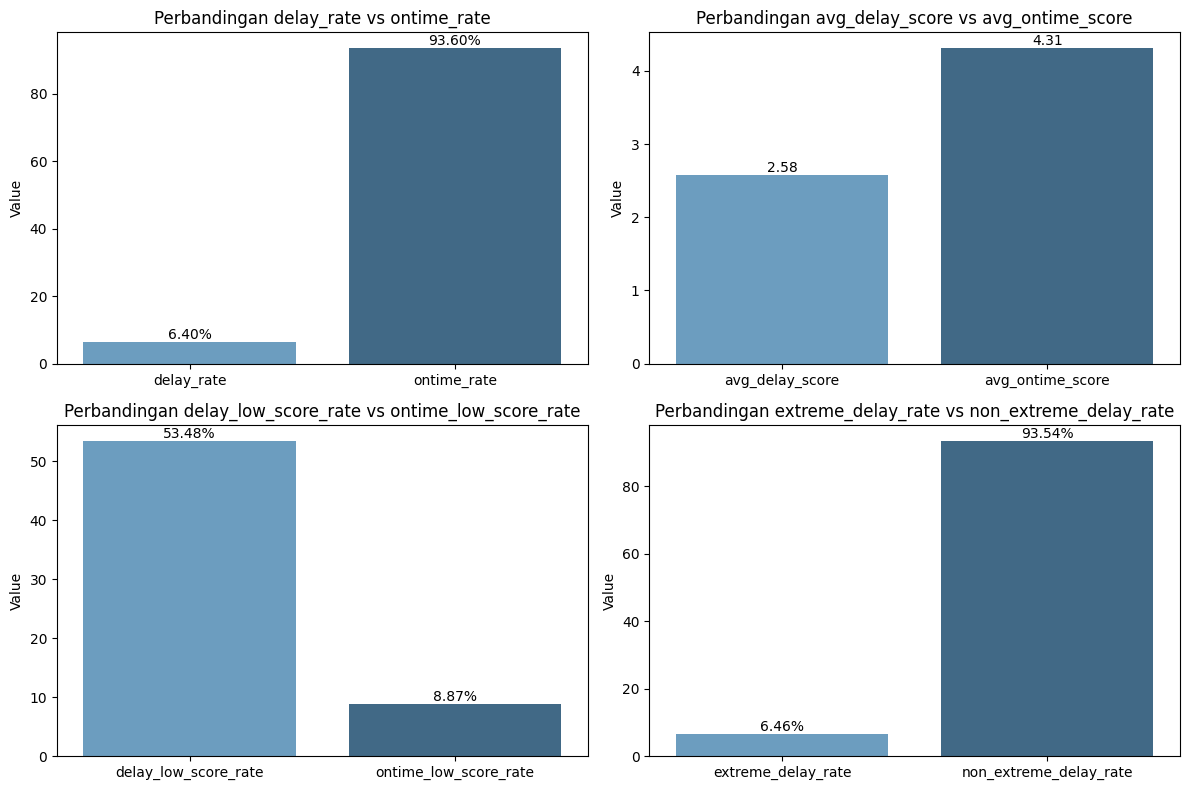

In [10]:
# Visualisasi Bar Chart
# Ambil data mulai dari indeks 1 sampai 8
df_kpi = summary_kpi.iloc[1:9].reset_index(drop=True)

# Menyiapkan canvas 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()  # Mengubah matriks 2x2 menjadi array 1D agar mudah diiterasi

# Membuat 4 plot secara bertahap (masing-masing 2 baris)
for i in range(4):
    start_idx = i * 2
    end_idx = start_idx + 2
    sub_df = df_kpi.iloc[start_idx:end_idx]

    # Membuat barplot
    sns.barplot(data=sub_df, x="kpi", y="value", ax=axes[i], palette="Blues_d")

    # Menambahkan label nilai di atas batang
    for p in axes[i].patches:
        height = p.get_height()
        axes[i].annotate(
            f"{height:.2f}%" if "rate" in sub_df["kpi"].values[0] else f"{height:.2f}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
        )

    axes[i].set_title(
        f"Perbandingan {sub_df['kpi'].iloc[0]} vs {sub_df['kpi'].iloc[1]}"
    )
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")

plt.tight_layout()
plt.show()


In [11]:
avg_extreme_score = df_mart.groupby('is_extreme_delay')['review_score'].mean()
print(f"Average Review Score by Extreme Delay : {avg_extreme_score.iloc[1].round(2)}")

avg_score_pct_change = (
    ((avg_delay_score.iloc[1] - avg_delay_score.iloc[0]) / avg_delay_score.iloc[0]) * 100
)

print(f"Average Score Percentage Change : {avg_score_pct_change:.2f}%")

Average Review Score by Extreme Delay : 1.93
Average Score Percentage Change : -40.16%


# KPI Summary
Berdasarkan perhitungan KPI, diketahui :
1. Sebagian besar (93.6%) pesanan on-time delivery dan sisanya (6.4%) delay delivery
2. Pesanan yang on-time memiliki rata-rata skor ulasan yang lebih tinggi dibanding pesanan yang terlambat
3. Dari 6.4% pesanan yang telat, lebih dari setengahnya memiliki skor ulasan < 3 dan 6.46% (360 order dari 5.574 order yang delay) diantaranya memiliki keterlambatan yang ekstrem atau sangat parah

Temuan tersebut memberikan informasi bahwa pesanan yang terlambat ke tangan customer, memiliki rata-rata skor ulasan yang rendah serta sebagian besar pesanan terlambat tersebut skornya < 3. 6.46% pesanan dari pesanan yang terlambat menjadi fokus prioritas karena menunjukkan aktivitas pengiriman yang sangat buruk.

# KPI by Customer State

In [12]:
display(df_mart)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,review_score,customer_state,diff_delivery_date,delay_status,is_extreme_delay,is_low_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,4.0,SP,7.11,0,0,0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,4.0,BA,5.36,0,0,0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,5.0,GO,17.25,0,0,0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,5.0,RN,12.98,0,0,0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,5.0,SP,9.24,0,0,0
...,...,...,...,...,...,...,...,...,...
87022,9c5dedf39a927c1b2549525ed64a053c,2017-03-17 15:08:01,2017-03-28,5.0,SP,10.37,0,0,0
87023,63943bddc261676b46f01ca7ac2f7bd8,2018-02-28 17:37:56,2018-03-02,4.0,SP,1.27,0,0,0
87024,83c1379a015df1e13d02aae0204711ab,2017-09-21 11:24:17,2017-09-27,5.0,BA,5.52,0,0,0
87025,11c177c8e97725db2631073c19f07b62,2018-01-25 23:32:54,2018-02-15,2.0,RJ,20.02,0,0,1


In [13]:
delay_state = df_mart[df_mart['delay_status'] == 1].groupby('customer_state').agg(
    total_order = ('order_id', 'size'),
    avg_review_score = ('review_score', 'mean'),
    extreme_delay_rate = ('is_extreme_delay', 'mean'),
    total_extreme_delay = ('is_extreme_delay', 'sum'),
    low_score_rate = ('is_low_score', 'mean')
).sort_values(by=['total_order', 'extreme_delay_rate'], ascending=[False, False]).round(2).reset_index()

delay_state['extreme_delay_rate'] *= 100
delay_state['low_score_rate'] *= 100

top_delay_state = delay_state.head(10).reset_index()
print(f"{round(len(top_delay_state) / len(delay_state) * 100, 2)}% Customer State Teratas menyumbang -> {round(top_delay_state['total_order'].sum() / delay_state['total_order'].sum() * 100, 2)}% Late Delivery Order")

display(top_delay_state)
display(delay_state)

37.04% Customer State Teratas menyumbang -> 84.95% Late Delivery Order


,index,customer_state,total_order,avg_review_score,extreme_delay_rate,total_extreme_delay,low_score_rate
0,0,SP,1445,3.01,4.0,57,41.0
1,1,RJ,1273,2.13,11.0,145,67.0
2,2,MG,426,2.80,3.0,14,47.0
3,3,BA,374,2.58,7.0,25,53.0
4,4,RS,293,2.53,4.0,12,55.0
5,5,SC,256,2.68,1.0,3,49.0
6,6,ES,189,2.83,4.0,8,47.0
7,7,PR,177,2.94,5.0,8,44.0
8,8,CE,165,2.19,13.0,22,63.0
9,9,PE,137,2.17,8.0,11,68.0


,customer_state,total_order,avg_review_score,extreme_delay_rate,total_extreme_delay,low_score_rate
0,SP,1445,3.01,4.0,57,41.0
1,RJ,1273,2.13,11.0,145,67.0
2,MG,426,2.80,3.0,14,47.0
3,BA,374,2.58,7.0,25,53.0
4,RS,293,2.53,4.0,12,55.0
5,SC,256,2.68,1.0,3,49.0
6,ES,189,2.83,4.0,8,47.0
7,PR,177,2.94,5.0,8,44.0
8,CE,165,2.19,13.0,22,63.0
9,PE,137,2.17,8.0,11,68.0


In [14]:
ontime_state = df_mart[df_mart['delay_status'] == 0].groupby('customer_state').agg(
    total_order = ('order_id', 'size'),
    avg_review_score = ('review_score', 'mean'),
    low_score_rate = ('is_low_score', 'mean')
).sort_values(by='total_order', ascending=False).round(2).reset_index()

top_ontime_state = ontime_state.head(10).reset_index()
print(f"{round(len(top_ontime_state) / len(ontime_state) * 100, 2)}% Customer State Teratas menyumbang -> {round(top_ontime_state['total_order'].sum() / ontime_state['total_order'].sum() * 100, 2)}% On-Time Delivery Order")

display(top_ontime_state)

37.04% Customer State Teratas menyumbang -> 90.97% On-Time Delivery Order


,index,customer_state,total_order,avg_review_score,low_score_rate
0,0,SP,35088,4.35,0.08
1,1,MG,9814,4.31,0.09
2,2,RJ,9788,4.26,0.11
3,3,RS,4584,4.33,0.08
4,4,PR,4263,4.32,0.09
5,5,SC,2932,4.32,0.08
6,6,BA,2575,4.17,0.11
7,7,DF,1792,4.28,0.09
8,8,GO,1682,4.25,0.10
9,9,ES,1582,4.30,0.08


In [15]:
# Customer State KPI Summary
summary_state = delay_state.merge(
    ontime_state,
    on='customer_state',
    how='outer',
    suffixes=("_delay", "_ontime")
)
summary_state['review_score_gap'] = (
    summary_state['avg_review_score_ontime'] - summary_state['avg_review_score_delay']
)

display(summary_state.sort_values(by=['extreme_delay_rate', 'review_score_gap'], ascending=[False, False]).reset_index(drop=True))

,customer_state,total_order_delay,avg_review_score_delay,extreme_delay_rate,total_extreme_delay,low_score_rate_delay,total_order_ontime,avg_review_score_ontime,low_score_rate_ontime,review_score_gap
0,AC,2,1.00,50.0,1,100.0,73,4.16,0.14,3.16
1,RR,4,2.00,50.0,2,75.0,34,4.18,0.06,2.18
2,AP,3,4.67,33.0,1,0.0,60,4.25,0.07,-0.42
3,AM,5,3.20,20.0,1,40.0,131,4.32,0.11,1.12
4,CE,165,2.19,13.0,22,63.0,989,4.26,0.09,2.07
5,RN,38,2.11,11.0,4,63.0,387,4.42,0.06,2.31
6,RJ,1273,2.13,11.0,145,67.0,9788,4.26,0.11,2.13
7,GO,115,2.59,9.0,10,50.0,1682,4.25,0.10,1.66
8,SE,40,1.98,8.0,3,68.0,257,4.28,0.10,2.30
9,PE,137,2.17,8.0,11,68.0,1298,4.31,0.09,2.14


In [16]:
final_state = summary_state.copy()
final_state['pct_score_change'] = (
    (
        (final_state['avg_review_score_delay'] - final_state['avg_review_score_ontime']) / final_state['avg_review_score_ontime']
    ) * 100
).round(2)

final_state = final_state.sort_values(by=['total_order_delay', 'pct_score_change'], ascending=[False, True]).reset_index(drop=True)
# display(final_state[['customer_state', 'total_order_delay', 'total_extreme_delay', 'pct_score_change']])
print(final_state)

   customer_state  total_order_delay  avg_review_score_delay  \
0              SP               1445                    3.01   
1              RJ               1273                    2.13   
2              MG                426                    2.80   
3              BA                374                    2.58   
4              RS                293                    2.53   
5              SC                256                    2.68   
6              ES                189                    2.83   
7              PR                177                    2.94   
8              CE                165                    2.19   
9              PE                137                    2.17   
10             GO                115                    2.59   
11             MA                107                    2.40   
12             DF                100                    2.38   
13             PA                 93                    2.18   
14             AL                 77    

In [17]:
MIN_SAMPLE = 30 

reliable_states = final_state[final_state['total_order_delay'] >= MIN_SAMPLE].copy()

threshold_volume = reliable_states['total_order_delay'].quantile(0.75)
threshold_impact = reliable_states['review_score_gap'].quantile(0.75)

reliable_states['flag_volume'] = reliable_states['total_order_delay'] >= threshold_volume
reliable_states['flag_impact'] = reliable_states['review_score_gap'] >= threshold_impact
reliable_states['priority'] = reliable_states['flag_volume'] | reliable_states['flag_impact']

reliable_states['tier'] = 'Tidak prioritas'
reliable_states.loc[reliable_states['flag_volume'] | reliable_states['flag_impact'], 'tier'] = 'Prioritas 2 (salah satu kriteria)'
reliable_states.loc[reliable_states['flag_volume'] & reliable_states['flag_impact'], 'tier'] = 'Prioritas 1 (dua kriteria)'

In [18]:
# display(final_state[['customer_state', 'total_order_delay', 'total_extreme_delay', 'pct_score_change']])
display(
    (reliable_states[['customer_state', 'total_order_delay', 'total_extreme_delay', 'pct_score_change', 'flag_volume', 'flag_impact', 'priority', 'tier']])
    .sort_values(by=['tier', 'total_order_delay'], ascending=[True, False])
)

,customer_state,total_order_delay,total_extreme_delay,pct_score_change,flag_volume,flag_impact,priority,tier
1,RJ,1273,145,-50.00,True,True,True,Prioritas 1 (dua kriteria)
0,SP,1445,57,-30.80,True,False,True,Prioritas 2 (salah satu kriteria)
2,MG,426,14,-35.03,True,False,True,Prioritas 2 (salah satu kriteria)
3,BA,374,25,-38.13,True,False,True,Prioritas 2 (salah satu kriteria)
4,RS,293,12,-41.57,True,False,True,Prioritas 2 (salah satu kriteria)
5,SC,256,3,-37.96,True,False,True,Prioritas 2 (salah satu kriteria)
8,CE,165,22,-48.59,False,True,True,Prioritas 2 (salah satu kriteria)
9,PE,137,11,-49.65,False,True,True,Prioritas 2 (salah satu kriteria)
14,AL,77,4,-50.23,False,True,True,Prioritas 2 (salah satu kriteria)
19,SE,40,3,-53.74,False,True,True,Prioritas 2 (salah satu kriteria)


In [19]:
abs_delay_order = total_order * (delay_rate.iloc[1] / 100)
abs_extreme_delay = abs_delay_order * (extreme_delay_rate.iloc[1] / 100)
abs_low_score_order = abs_delay_order * (low_score_rate.iloc[1] / 100)

print(abs_delay_order)
print(abs_extreme_delay.round(2))
print(abs_low_score_order.round(2))

5574.0
360.08
2981.0


In [20]:
reliable_states['pct_order_delay'] = (
    (reliable_states['total_order_delay'] / abs_delay_order) * 100
).round(2)

reliable_states['pct_extreme_delay'] = (
    (reliable_states['total_extreme_delay'] / abs_extreme_delay) * 100
).round(2)

reliable_states['pct_low_score'] = (
    (reliable_states['total_extreme_delay'] / abs_extreme_delay) * 100
)

display(
    (reliable_states[['customer_state', 'total_order_delay', 'pct_order_delay', 'total_extreme_delay', 'pct_extreme_delay', 'pct_score_change', 'flag_volume', 'flag_impact', 'priority', 'tier']])
    .sort_values(by=['tier', 'total_order_delay'], ascending=[True, False])
)

,customer_state,total_order_delay,pct_order_delay,total_extreme_delay,pct_extreme_delay,pct_score_change,flag_volume,flag_impact,priority,tier
1,RJ,1273,22.84,145,40.27,-50.00,True,True,True,Prioritas 1 (dua kriteria)
0,SP,1445,25.92,57,15.83,-30.80,True,False,True,Prioritas 2 (salah satu kriteria)
2,MG,426,7.64,14,3.89,-35.03,True,False,True,Prioritas 2 (salah satu kriteria)
3,BA,374,6.71,25,6.94,-38.13,True,False,True,Prioritas 2 (salah satu kriteria)
4,RS,293,5.26,12,3.33,-41.57,True,False,True,Prioritas 2 (salah satu kriteria)
5,SC,256,4.59,3,0.83,-37.96,True,False,True,Prioritas 2 (salah satu kriteria)
8,CE,165,2.96,22,6.11,-48.59,False,True,True,Prioritas 2 (salah satu kriteria)
9,PE,137,2.46,11,3.05,-49.65,False,True,True,Prioritas 2 (salah satu kriteria)
14,AL,77,1.38,4,1.11,-50.23,False,True,True,Prioritas 2 (salah satu kriteria)
19,SE,40,0.72,3,0.83,-53.74,False,True,True,Prioritas 2 (salah satu kriteria)


In [21]:
# atau lebih simpel, cek korelasi
reliable_states[['total_order_delay','total_extreme_delay']].corr()

,total_order_delay,total_extreme_delay
total_order_delay,1.000000,0.846179
total_extreme_delay,0.846179,1.000000


In [22]:
reliable_states[['pct_order_delay','pct_low_score']].corr()

,pct_order_delay,pct_low_score
pct_order_delay,1.00000,0.84625
pct_low_score,0.84625,1.00000


In [23]:
reliable_states[['review_score_gap','pct_score_change']].corr()

,review_score_gap,pct_score_change
review_score_gap,1.000000,-0.995337
pct_score_change,-0.995337,1.000000


In [24]:
# Final Priority Table
reliable_states.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_state           21 non-null     str    
 1   total_order_delay        21 non-null     int64  
 2   avg_review_score_delay   21 non-null     float64
 3   extreme_delay_rate       21 non-null     float64
 4   total_extreme_delay      21 non-null     int64  
 5   low_score_rate_delay     21 non-null     float64
 6   total_order_ontime       21 non-null     int64  
 7   avg_review_score_ontime  21 non-null     float64
 8   low_score_rate_ontime    21 non-null     float64
 9   review_score_gap         21 non-null     float64
 10  pct_score_change         21 non-null     float64
 11  flag_volume              21 non-null     bool   
 12  flag_impact              21 non-null     bool   
 13  priority                 21 non-null     bool   
 14  tier                     21 non-null   

In [25]:
final_priority = reliable_states[['customer_state', 'total_order_delay', 'pct_order_delay', 'total_extreme_delay', 'pct_extreme_delay', 'pct_score_change', 'flag_volume', 'flag_impact', 'priority', 'tier']]
final_priority = final_priority.sort_values(by=['tier', 'total_order_delay'], ascending=[True, False]).reset_index(drop=True)

display(final_priority)

,customer_state,total_order_delay,pct_order_delay,total_extreme_delay,pct_extreme_delay,pct_score_change,flag_volume,flag_impact,priority,tier
0,RJ,1273,22.84,145,40.27,-50.00,True,True,True,Prioritas 1 (dua kriteria)
1,SP,1445,25.92,57,15.83,-30.80,True,False,True,Prioritas 2 (salah satu kriteria)
2,MG,426,7.64,14,3.89,-35.03,True,False,True,Prioritas 2 (salah satu kriteria)
3,BA,374,6.71,25,6.94,-38.13,True,False,True,Prioritas 2 (salah satu kriteria)
4,RS,293,5.26,12,3.33,-41.57,True,False,True,Prioritas 2 (salah satu kriteria)
5,SC,256,4.59,3,0.83,-37.96,True,False,True,Prioritas 2 (salah satu kriteria)
6,CE,165,2.96,22,6.11,-48.59,False,True,True,Prioritas 2 (salah satu kriteria)
7,PE,137,2.46,11,3.05,-49.65,False,True,True,Prioritas 2 (salah satu kriteria)
8,AL,77,1.38,4,1.11,-50.23,False,True,True,Prioritas 2 (salah satu kriteria)
9,SE,40,0.72,3,0.83,-53.74,False,True,True,Prioritas 2 (salah satu kriteria)


In [26]:
print(360 / 5574 * 100)

6.458557588805166


In [27]:
# Analisis Delay
df_delay = df_mart[df_mart['delay_status'] == 1]

print("=== Delayed Order Overview ===")
print(f"Total Delayed Order                 : {df_delay.shape[0]}")
print(f"Total Delayed Order which 'Good'    : {df_delay[df_delay['is_low_score'] == 0].shape[0]}")
print(f"Total Delayed Order which 'Bad'     : {df_delay[df_delay['is_low_score'] == 1].shape[0]} \n")

print("=== Good Delayed Order - Review Score ===")
print(df_delay[df_delay['is_low_score'] == 0]['review_score'].describe().round(2).T)
print("=== Bad Delayed Order - Review Score ===")
print(df_delay[df_delay['is_low_score'] == 1]['review_score'].describe().round(2).T, '\n')

bad_delay = df_delay[df_delay['is_low_score'] == 1]

print("=== Percentage Extreme Delay - Bad Delayed Order ===")
print(f"Percent of Extreme Delay in Bad Delayed Order : {(bad_delay['is_extreme_delay'].mean() * 100).round(2)}% or {(bad_delay['is_extreme_delay'].shape[0] / df_delay[df_delay['is_extreme_delay'] == 1].shape[0] * 100)}")

=== Delayed Order Overview ===
Total Delayed Order                 : 5574
Total Delayed Order which 'Good'    : 2593
Total Delayed Order which 'Bad'     : 2981 

=== Good Delayed Order - Review Score ===
count    2593.00
mean        4.23
std         0.82
min         3.00
25%         4.00
50%         4.00
75%         5.00
max         5.00
Name: review_score, dtype: float64
=== Bad Delayed Order - Review Score ===
count    2981.00
mean        1.14
std         0.35
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         2.00
Name: review_score, dtype: float64 

=== Percentage Extreme Delay - Bad Delayed Order ===
Percent of Extreme Delay in Bad Delayed Order : 8.59% or 828.0555555555555


In [29]:
df_mart.to_pickle('df_mart.pkl')

In [30]:
reliable_states[['pct_score_change', 'low_score_rate_delay']].corr()

,pct_score_change,low_score_rate_delay
pct_score_change,1.000000,-0.966442
low_score_rate_delay,-0.966442,1.000000
